In [ ]:
# # %%capture

# # Install the PyBolt package directly from Github
# %pip install git+https://github.com/Maxim-Laletin/PyBolt.git@setup-package

# # Install the torch
# %pip install torch

# # Install pandas
# %pip install pandas

In [ ]:
import torch
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import pandas as pd
from copy import deepcopy
from scipy.integrate import solve_ivp # ODE solver
from scipy.special import kn # Bessel function
from scipy.interpolate import interp1d, CubicSpline # interpolation
from scipy.integrate import quad # integration

from PyBolt import cosmology 
from PyBolt import fBE_solver as fBE


# Defining functions

NOW WE CAN USE THE COSMOLOGY PACKAGE FOR THE QUANTITIES USED IN THIS CODE. PLEASE CHECK WHICH QUANTITIES ARE USED AND REWRITE THEM AS SOME OF THEM BELOW

In [ ]:

Hubble = cosmology.H

gs = cosmology.h_s

gTilde = cosmology.gtilda

HubbleTilde = cosmology.H_t


In [4]:
massRatio=0.5

# The mass of the mother particle (MP)
m1 = 1.776 # (tau) GeV
# The mass of the daughter particle (DP)
m2 = 0.10565 # (muon) GeV
# The mass of the DM particle
mDM = 1e-10 # GeV

# PQ symmetry breaking scale
fa = 2e+6 # GeV
# corresponds to the freeze out

# Ratio of the two masses
mu = m2/m1

# Number of massless particle degrees of freedom
g_x = 1.0
# Number of MP dofs
g_m1 = 2.0
# Number of DP dofs
g_m2 = 2.0

# Coupling of MP-DP-x
yMDx = 1

# Decay width of MP -> DP + x
Gamma = yMDx**2*m1**3*(1-(m2/m1)**2)**3/64/np.pi/fa**2 # GeV
# Msquared for the decay

Msq= yMDx**2*m1**4*(1 - (m2/m1)**2)**2/4/fa**2 # GeV^2

# Numerical solution:

We calculate the phase-space distribution using PyBolt package

In [ ]:
# Create a model of axion phase-space evolution
AxionModel = fBE.Model(m1,mDM,g_x,'b')
# m1 is the mass of the heaviest particle in the reaction

# Create an instance of the DecayToX process class
Decay = fBE.DecayToX(m1,m2,g_m1,Msq,Gamma)

# Create the grid of x and q
N_x = 500 # number of x points
N_q = 200 # number of q points
x0 = 1.0  # starting x value
xf = 20.0 # final x value

q0 = 0.0001 # smallest q value
qf = 20. # biggest q value

# Creating vectors of linearly distributed values of x and q
x_lin = np.linspace(x0,xf,N_x)
q_lin = np.linspace(q0,qf,N_q)

# Assigning the grid (of x and q) to the model
AxionModel.changeGrid(x_lin,q_lin)

# Add the decay collision integral to the model collision term (the only process that we consider)
AxionModel.addCollisionTerm(Decay.collisionTerm)

# Initial distribution
#f0 = np.zeros_like(q_lin)
f0 = AxionModel.equilibriumFunction(q_lin)

# fBE solver options
solver_options = {
    'method': 'BDF', # Implicit backward differentiation formula method of variable order (1-5) - because the equation is stiff
    'atol': 1e-5,   # Absolute tolerance
    'rtol': 1e-3   # Relative tolerance
}

# Solving the fBE
AxionModel.solve_fBE(f0,solver_options)

# Creating the kymograph plot of the solution
# AxionModel.plot2D()

fBE solved in 0.36 seconds


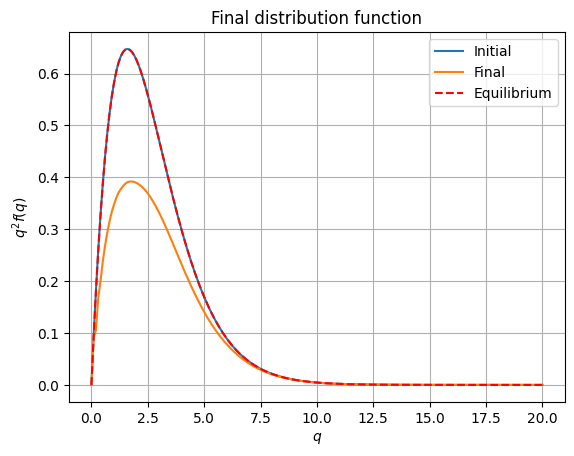

In [7]:
# Plot the initial and final solutions and the equilibrium distribution to compare
plt.figure()
plt.plot(q_lin,f0, label = 'Initial')
plt.plot(q_lin, AxionModel.getSolution()[-1,:], label = 'Final')
plt.plot(q_lin, AxionModel.equilibriumFunction(q_lin),'r--', label = 'Equilibrium')
plt.xlabel(r'$q$')
plt.ylabel(r'$q^2 f(q)$')
plt.title("Final distribution function")
plt.legend(loc="upper right")
plt.grid()
plt.show()

# PINN


In [8]:
def _construct_FC_layers(hidden, input_dim, output_dim, activations):
    """Constructs the layer structure for a fully connected neural network.
      returns list of layers
    """
    layers = []
    layers.append(torch.nn.Linear(input_dim, hidden[0]))
    layers.append(activations)
    for i in range(len(hidden)-1):
        layers.append(torch.nn.Linear(hidden[i], hidden[i+1]))
        layers.append(activations)
    layers.append(torch.nn.Linear(hidden[-1], output_dim))
    return layers

def normalize(x, x_min, x_max):
    """scales [x_min, x_max] to [-1, 1] range"""
    return 2.*(x-x_min)/(x_max-x_min) -1

class FCN(torch.nn.Module):
    """A simple fully connected neural network.

    Parameters
    ----------
    input_dim : int
        The space of the points the can be put into this model.
    output_dim : int
        The space of the points returned by this model.
    hidden : list or tuple
        The number and size of the hidden layers of the neural network.
        The lenght of the list/tuple will be equal to the number
        of hidden layers, while the i-th entry will determine the number
        of neurons of each layer.
        E.g hidden = (10, 5) -> 2 layers, with 10 and 5 neurons.
    activations : torch.nn, optional
        The activation functions of this network. Deafult is nn.Tanh().
    """
    def __init__(self,
                 input_dim,
                 output_dim,
                 hidden=(20,20,20),
                 activations=torch.nn.Tanh(), # check other activation functions, simgoid might be better as it is more 0 centered and Y~0??
                 normalize=False,
                 x_max = None,
                 x_min = None
                ):
        super().__init__()

        self.normalize = normalize
        if self.normalize:
            self.register_buffer('x_max', torch.tensor(x_max).float())
            self.register_buffer('x_min', torch.tensor(x_min).float())
        layers = _construct_FC_layers(hidden=hidden, input_dim=input_dim,
                                      output_dim=output_dim,
                                      activations=activations)

        self.sequential = torch.nn.Sequential(*layers)

    def forward(self, *x):
        x = torch.cat(x, dim=-1) # concatenate along last dimension
        if self.normalize:
            x = normalize(x, self.x_min, self.x_max)
        return self.sequential(x)

In [9]:
def grad(model_out, *derivative_variable):
    '''Computes the gradient of a network with respect to the given variable.
    Parameters
    ----------
    model_out : torch.tensor
        The (scalar) output tensor of the neural network
    derivative_variable : torch.tensor
        The input tensor of the variables in which respect the derivatives have to
        be computed
    Returns
    ----------
    torch.tensor
        A Tensor, where every row contains the values of the the first
        derivatives (gradient) w.r.t the row of the input variable.
    '''
    grad = []
    for vari in derivative_variable:
        new_grad = torch.autograd.grad(model_out.sum(), vari,
                                       create_graph=True, allow_unused=True)[0]
        grad.append(new_grad)
    return torch.column_stack(grad)

In [10]:
def uniform_sampler(batch_size, x_min, x_max):
    """
    Samples uniformly from the given ranges for each dimension.

    Parameters:
    - batch_size (int): Number of samples to generate.
    - x_min (list or torch.Tensor): Lower bounds for each dimension.
    - x_max (list or torch.Tensor): Upper bounds for each dimension.

    Returns:
    - x (torch.Tensor): Tensor of shape (batch_size, len(x_min)) containing the samples.
    """
    x_min = torch.tensor(x_min).float()
    x_max = torch.tensor(x_max).float()

    # Generate uniform samples in the range [0, 1]
    rand_samples = torch.rand(batch_size, len(x_min))

    # Scale and shift the samples to the desired range
    samples = x_min + (x_max - x_min) * rand_samples

    return samples

In [ ]:
device= 'cuda' if torch.cuda.is_available() else 'cpu'

data_loss_function = torch.nn.functional.mse_loss

def physics_loss_function(residual):
    return torch.mean(residual**2)
  


def InitialCondition(q):
  feq= q**2/(torch.exp(q) - 1.0)
  return feq


def InitialCondition_residual(f,x,q):
  feq= q**2/(torch.exp(q) - 1.0)
  return f(x,q)-feq


def FullBoltzmannEquation_residual_torch(f,x,q):
  massRatio=0.5
  m1=1
  m2=0.5
  fa=4e8
  g_x=1
  yMDx=1
  Gamma = yMDx**2*m1**3*(1-(m2/m1)**2)**3/64/np.pi # GeV
  Msq= yMDx**2*m1**4*(1 - (m2/m1)**2)**2/4/fa**2 # GeV^2
  Elim1 = torch.max(torch.stack([x*(torch.ones(q.shape).to(device)), x*massRatio+q, x**2*(1 + 4*q**2/(x**2*(1-massRatio**2)) - (1-massRatio**2) )/4/q],dim=1),1)
  Elim2 = torch.max(torch.stack([x-q, x*massRatio*(torch.ones(q.shape).to(device)), x**2/4/q],dim=1),1)
  gradient=grad(f(x,q),x,q)
  dY_dq = gradient[:,1]
  dY_dt=gradient[:,0]
  feq= q**2/(torch.exp(q) - 1.0)
  #(gTilde(m1/t)*(dY_dx*Momentum_x[:,0] - 2*state) + q2CollTerm/HubbleTilde(m1/t))/t
  q2CollTerm = (((2*x*Msq/16/np.pi/g_x/q**2)*(torch.log((1+torch.exp(-Elim1.values))/(1+torch.exp(-Elim2.values))))))*(f(x,q) - feq)
  gTildeInternal=torch.from_numpy(gTilde(m1/x.cpu().detach().numpy())).to(device)
  HubbleTildeInternal=torch.from_numpy(HubbleTilde(m1/x.cpu().detach().numpy())).to(device)
  return dY_dt-(gTildeInternal*(dY_dq*q - 2*f(x,q))+q2CollTerm/HubbleTildeInternal)/x

# Learning

In [22]:
class TrainingBoltzmaNN:
    def __init__(
        self,
        hidden_width,
        collocation_number_plot=100,
    ):
        # Initialize the neural network model
        self.model_f = FCN(
            input_dim=2,
            output_dim=1,
            hidden=(hidden_width, hidden_width),
            normalize=True,
            x_min=[x0, q0],
            x_max=[xf, qf],
            activations=nn.Tanh(),
        )
        self.model_f.to(device)

        

        self.collocation_number_plot = collocation_number_plot

    def train(self, num_epochs,batch_size,physics_weight,bc_weight=1,positivity_weight=1,
        learning_rate=1e-2,patience=1000,optimizer_class=torch.optim.Adam, scheduler_class=ReduceLROnPlateau,
):
        self.model_f.train()
        history = []
        mse_numerical = []
        
        # Set up optimizer and scheduler
        self.optimizer = optimizer_class(
            self.model_f.parameters(), lr=learning_rate
        )
        self.scheduler = scheduler_class(
            self.optimizer,
            factor=0.5,
            patience=patience,
            min_lr=1e-5,
            threshold=1e-5,
            eps=0,
        )

        # Prepare plotting data
        q_values = torch.linspace(
            q0, qf, steps=self.collocation_number_plot
        ).reshape(-1, 1).to(device)
        x_values_fin = torch.full_like(q_values, xf).to(device)
        x_values_ini = torch.full_like(q_values, x0).to(device)
        X_plot = q_values.cpu().detach().numpy()
        NumericalFinalDistribution=AxionModel.getSolution()[-1,:]

        for epoch in range(num_epochs):
            self.optimizer.zero_grad()

            # Sample collocation points for PDE residual
            x_sample = uniform_sampler(batch_size, [x0], [xf]).to(device)
            q_sample = uniform_sampler(batch_size, [q0], [qf]).to(device)
            x_grid, q_grid = torch.meshgrid(
                x_sample.squeeze(), q_sample.squeeze(), indexing="ij"
            )
            x_grid = x_grid.reshape(-1, 1).requires_grad_(True)
            q_grid = q_grid.reshape(-1, 1).requires_grad_(True)

            # Compute PDE residual and loss
            physics_residual = FullBoltzmannEquation_residual_torch(
                self.model_f, x_grid, q_grid
            )
            physics_loss = physics_loss_function(physics_residual)
            physics_loss_weighted = physics_weight * physics_loss

            # Sample points for boundary conditions at q = q0 and q = qf
            x_bc = uniform_sampler(batch_size, [x0], [xf]).to(device)
            q_bc_0 = torch.full((batch_size, 1), q0).to(device)
            q_bc_f = torch.full((batch_size, 1), qf).to(device)
            bc_loss_0 = physics_loss_function(self.model_f(x_bc, q_bc_0))
            bc_loss_f = physics_loss_function(self.model_f(x_bc, q_bc_f))
            bc_loss = bc_loss_0 + bc_loss_f

            # Sample points for initial condition at x = x0
            q_ini = uniform_sampler(batch_size, [q0], [qf]).to(device)
            x_ini = torch.full((batch_size, 1), x0).to(device)
            ini_residual = InitialCondition_residual(
                self.model_f, x_ini, q_ini
            )
            ini_loss = physics_loss_function(ini_residual)

            # Total boundary condition loss
            bc_total_loss = bc_weight * (bc_loss + ini_loss)

            # Enforce positivity of the solution
            output = self.model_f(x_grid, q_grid)
            positivity_loss = positivity_weight * physics_loss_function(
                torch.relu(-output)
            )

            # Total loss
            total_loss = physics_loss_weighted + bc_total_loss + positivity_loss
            total_loss.backward()

            # Update optimizer and scheduler
            self.optimizer.step()
            self.scheduler.step(total_loss)

            # Logging
            current_lr = self.optimizer.param_groups[0]["lr"]
            losses = {
                "boundary": bc_total_loss.item(),
                "physics": physics_loss_weighted.item(),
                "positivity": positivity_loss.item(),
                "total_loss": total_loss.item(),
                "learning_rate": current_lr,
            }
            history.append(losses)

            # Compute MSE with numerical solution every 500 epochs
            if epoch % 500 == 0:
                with torch.no_grad(): #prevent unnecessary calculation of derivatives
                    nn_final = self.model_f(
                        x_values_fin, q_values
                    ).cpu().numpy().squeeze()
                mse = np.sqrt(
                    np.mean((NumericalFinalDistribution - nn_final) ** 2)
                )
                mse_numerical.append(mse)
                print(f"Epoch {epoch}, Losses: {losses}")
                print(f"MSE w.r.t numerical solution: {mse}")

            # Plot results every 1000 epochs
            if epoch % 1000 == 0 and epoch != 0:
                with torch.no_grad():
                    nn_final = self.model_f(
                        x_values_fin, q_values
                    ).cpu().numpy().squeeze()
                    nn_initial = self.model_f(
                        x_values_ini, q_values
                    ).cpu().numpy().squeeze()

                plt.figure(figsize=(5, 3))
                plt.plot(X_plot, nn_final, label="PINN final", color="g")
                plt.plot(X_plot, nn_initial, label="PINN initial", color="r")
                plt.plot(q_lin, NumericalFinalDistribution, label = 'Numerical final')
                plt.plot(q_lin, AxionModel.getSolution()[0,:], label = 'Numerical initial')
                
                plt.xlabel("q")
                plt.ylabel("q^2 f(q)")
                plt.title(f"Prediction vs Actual Values at Epoch {epoch}")
                plt.legend()
                plt.show()

        # Convert history to DataFrame for analysis
        history_df = pd.DataFrame(history)
        mse_numerical = np.array(mse_numerical)

        # Plot relative error
        plt.figure(figsize=(5, 3))
        relative_error = np.abs(nn_final / NumericalFinalDistribution)
        plt.semilogy(X_plot, relative_error, label="Relative Error", color="g")
        plt.xlabel("q")
        plt.ylabel("Relative Error")
        plt.title(f"Relative Error at Epoch {epoch}")
        plt.legend()
        plt.show()

        # Plot physics loss over epochs
        plt.figure(figsize=(5, 3))
        plt.semilogy(history_df["physics"], color="blue")
        plt.xlabel("Epoch")
        plt.ylabel("Physics Loss")
        plt.title("Physics Loss over Epochs")
        plt.show()

        # Plot MSE over epochs
        epochs = np.arange(0, num_epochs, 500)
        plt.figure(figsize=(5, 3))
        plt.semilogy(epochs, mse_numerical, color="red")
        plt.xlabel("Epoch")
        plt.ylabel("MSE")
        plt.title("MSE w.r.t Numerical Solution over Epochs")
        plt.show()

Epoch 0, Losses: {'boundary': 0.1037520170211792, 'physics': 0.0001983813394444374, 'positivity': 0.01564067415893078, 'total_loss': 0.11959107251955442, 'learning_rate': 0.01}
MSE w.r.t numerical solution: 0.13058844297108418
Epoch 500, Losses: {'boundary': 0.0015956180868670344, 'physics': 0.001857949835681134, 'positivity': 1.1045952305721585e-05, 'total_loss': 0.00346461387485389, 'learning_rate': 0.01}
MSE w.r.t numerical solution: 0.14433176673703088
Epoch 1000, Losses: {'boundary': 0.002290185075253248, 'physics': 0.0007339339307950205, 'positivity': 8.670597573257055e-10, 'total_loss': 0.003024119873108026, 'learning_rate': 0.01}
MSE w.r.t numerical solution: 0.1474140728722374


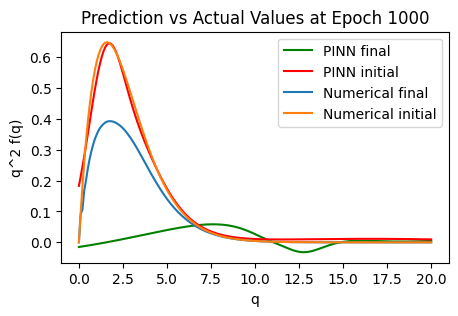

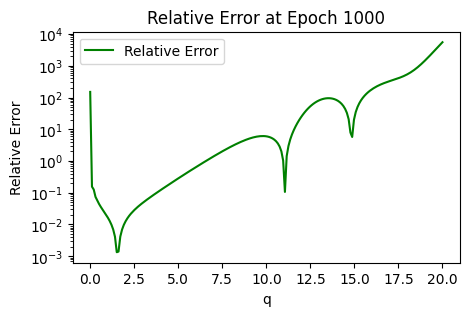

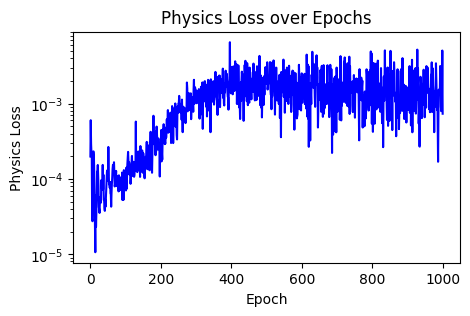

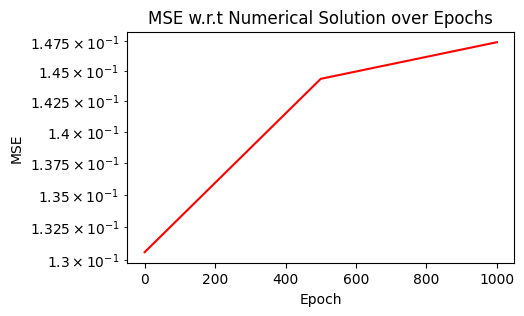

In [23]:
training1=TrainingBoltzmaNN(hidden_width=32,collocation_number_plot=N_q)
training1.train(num_epochs=1001,batch_size=25,physics_weight=1,bc_weight=1,patience=1000)
